## Implementing a dummy binary-classifier with fit-predict interface

#### Qa  Load and display the MNIST data

The MNIST database consists of handwritten digits and has a training set of 60,000 examples. It’s retrieved from openml.org, and each digit in the dataset is a 28x28-pixel image.

The value of X[0] is: 5


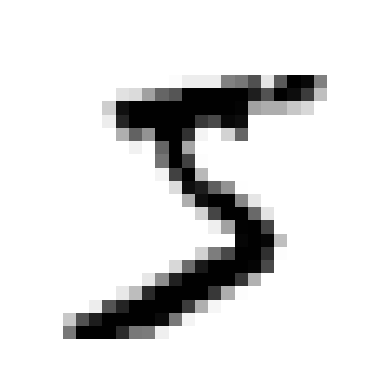

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import fetch_openml

def MNIST_GetDataSet():
    return fetch_openml('mnist_784', return_X_y=True, as_frame=False)

def MNIST_PlotDigit(data):
    import matplotlib
    import matplotlib.pyplot as plt
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")
    plt.show()


X, y = MNIST_GetDataSet()
print(f'The value of X[0] is: {y[0]}')
MNIST_PlotDigit(X[0])

Parameteren `return_X_y` gør, at `fetch_openml` returnerer et tuple `(data, target)` i stedet for en Bunch-container, der ellers indeholder flere oplysninger om datasættet.  
Når datasættet er hentet, kan et enkelt ciffer vises med funktionen `MNIST_PlotDigit(data)`.

Det ses på den ovenstående output at "The value of X[0] is 5" og plottet viser det enkelte håndskrevne ciffer, der findes på samme plads.


#### Qb  Add a Stochastic Gradient Decent [SGD] Classifier

Create a train-test data-set for MNIST and then add the `SGDClassifier` as done in [HOML], p.103.

Split your data and run the fit-predict for the classifier using the MNIST data.(We will be looking at cross-validation instead of the simple fit-predict in a later exercise.)

Notice that you have to reshape the MNIST X-data to be able to use the classifier. It may be a 3D array, consisting of 70000 (28 x 28) images, or just a 2D array consisting of 70000 elements of size 784.

A simple `reshape()` could fix this on-the-fly:
```python
X, y = MNIST_GetDataSet()

print(f"X.shape={X.shape}") # print X.shape= (70000, 28, 28)
if X.ndim==3:
    print("reshaping X..")
    assert y.ndim==1
    X = X.reshape((X.shape[0],X.shape[1]*X.shape[2]))
assert X.ndim==2
print(f"X.shape={X.shape}") # X.shape= (70000, 784)
```

Remember to use the category-5 y inputs

```python
y_train_5 = (y_train == '5')    
y_test_5  = (y_test == '5')
```
instead of the `y`'s you are getting out of the dataloader. In effect, we have now created a binary-classifier, that enable us to classify a particular data sample, $\mathbf{x}(i)$ (that is a 28x28 image), as being a-class-5 or not-a-class-5. 

Test your model on using the test data, and try to plot numbers that have been categorized correctly. Then also find and plots some misclassified numbers.

In [ ]:
# TODO: add your code here..
assert False, "TODO: solve Qb, and remove me.."

#### Qc Implement a dummy binary classifier

Now we will try to create a Scikit-learn compatible estimator implemented via a python class. Follow the code found on p.107 3rd [HOML] (for [HOML] 1. and 2. editions: name you estimator `DummyClassifier` instead of `Never5Classifyer`).

Here our Python class knowledge comes into play. The estimator class hierarchy looks like

<img src="https://itundervisning.ase.au.dk/SWMAL/L02/Figs/class_base_estimator.png" alt="WARNING: could not get image from server." style="width:500px">

All Scikit-learn classifiers inherit from `BaseEstimator` (and possibly also `ClassifierMixin`), and they must have a `fit-predict` function pair (strangely not in the base class!) and you can actually find the `sklearn.base.BaseEstimator` and `sklearn.base.ClassifierMixin` python source code somewhere in you anaconda install dir, if you should have the nerves to go to such interesting details.

But surprisingly you may just want to implement a class that contains the `fit-predict` functions, ___without inheriting___ from the `BaseEstimator`, things still work due to the pythonic 'duck-typing': you just need to have the class implement the needed interfaces, obviously `fit()` and `predict()` but also the more obscure `get_params()` etc....then the class 'looks like' a `BaseEstimator`...and if it looks like an estimator, it _is_ an estimator (aka. duck typing).

Templates in C++ also allow the language to use compile-time duck typing!

> https://en.wikipedia.org/wiki/Duck_typing

Call the fit-predict on a newly instantiated `DummyClassifier` object, and find a way to extract the accuracy `score` from the test data. You may implement an accuracy function yourself or just use the `sklearn.metrics.accuracy_score` function. 

Finally, compare the accuracy score from your `DummyClassifier` with the scores found in [HOML] "Measuring Accuracy Using Cross-Validation", p.107. Are they comparable? 

(Notice that Scikit-learn now also have a `sklearn.dummy.DummyClassifier`, but you are naturally supposed to create you own...)

In [ ]:
# TODO: add your code here..
assert False, "TODO: solve Qc, and remove me.."

### Qd Conclusion

Now, conclude on all the exercise above. 

Write a short textual conclusion (max. 10- to 20-lines) that extract the _essence_ of the exercises: why did you think it was important to look at these particular ML concepts, and what was our overall learning outcome of the exercises (in broad terms).

In [ ]:
# TODO: Qd concluding remarks in text..

REVISIONS||
:- | :- |
2018-12-19| CEF, initial.
2018-02-06| CEF, updated and spell checked.
2018-02-08| CEF, minor text update.
2018-03-05| CEF, updated with SHN comments.
2019-09-02| CEF, updated for ITMAL v2.
2019-09-04| CEF, updated and added conclusion Q.
2020-01-25| CEF, F20 ITMAL update.
2020-02-04| CEF, updated page numbers to HOMLv2.
2020-09-03| CEF, E20 ITMAL update, udpated figs paths.
2020-09-06| CEF, added alt text.
2020-09-18| CEF, added binary-classifier text to Qb to emphasise 5/non-5 classification.
2021-01-12| CEF, F21 ITMAL update, moved revision tabel.
2021-08-02| CEF, update to E21 ITMAL.
2022-01-25| CEF, update to F22 SWMAL.
2023-02-07| CEF, update HOML page numbers.
2024-02-14| CEF, added note on sklearn.dummy.DummyClassifier.
2024-09-13| CEF, updated p.107 and editions text references.